In [83]:
# import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from mpmath import hyp1f1

# import relevant constants
from astropy.constants import M_sun, G, c
from scipy.constants import pi
from astropy.constants import M_sun

# figure format
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ['Computer Moden Roman']
})

### Phase Function and the Fresnel Number

The transmission factor, written in terms of the dimensionless frequency $\nu$, is

$$F = -i \nu \int \int  e^{2\pi i \nu \tau(\mathbf{x},\mathbf{y})} d^2 \mathbf{x}$$

where $\tau (\mathbf{x}, \mathbf{y}) = \displaystyle \frac{1}{2}(\mathbf{x} - \mathbf{y})^2 - \psi(\mathbf{x}) + \psi_0$ is a dimensionless scalar function related to the Fermat potential or the time-delay function. The parameter $\nu$ is related to the diffraction effects in gravitational lensing and its effect are studied by looking at the phase function 

$$\Phi(\mathbf{x}) = \arg \big[2\pi i \nu \tau(\mathbf{x}, \mathbf{y})\big] \qquad , \qquad -\pi \leq \Phi \leq \pi \quad .$$

To study the effects of $\nu$, we follow reference [1]. Here, we note the lens plane with image position $\mathbf{x} = (x,x')$, which depend parametrically on $\mathbf{y}$. Two cases were considered a) no gravitational potential and b) with gravitational potential, both along the line of sight. For both cases, the following were considered: $\nu = 1, 4, 10$ , $\mathbf{y} = (1,0)$.

In [84]:
# function for the dimensionless time dela
def phase_PML(X, Y, ys, nu, psi=False, psi0 = 0):

    from numpy import exp, log, sqrt, angle
    from scipy.constants import pi

    k = 2 * pi * nu * 1j

    tauGeom = 0.5*((X-ys[0])**2 + (Y-ys[1])**2)                 # geometric time delay

    if psi==True:                                               # gravitational time delay
        tauGrav = log(sqrt(X**2 + Y**2))
    else:
        tauGrav = 0

    tau = tauGeom - tauGrav + psi0                              # phase

    arg = angle(exp(k*tau))                                     # argument of the exponential

    return arg

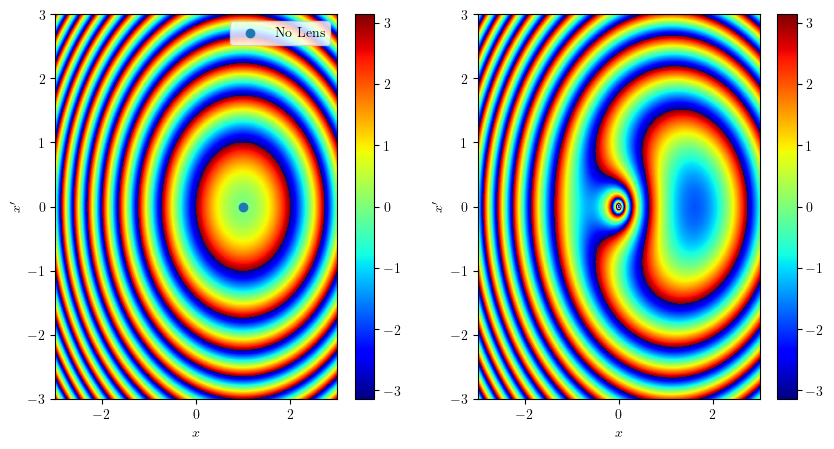

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(10,5))

x = np.linspace(-3, 3, 2000)
y = np.linspace(-3, 3, 2000)

X, Y =  np.meshgrid(x,y)

# lensing parameters
nu = 1.0
ys = (1.0, 0.0)


# phase map w/o lens

phase0 = phase_PML(X=X, Y=Y, ys=ys, nu=nu, psi=False)
ax0 = ax[0].pcolormesh(X, Y, phase0, cmap='jet')
ax[0].scatter(1, 0, label="No Lens", edgecolor='white', s=100)
ax[0].set_xlabel(r"$x$")
ax[0].set_ylabel(r"$x'$")
ax[0].legend()

fig.colorbar(ax0)


# phase map w/ lens

phase1 = phase_PML(X=X, Y=Y, ys=ys, nu=nu, psi=True)
ax1 = ax[1].pcolormesh(X, Y, phase1, cmap='jet')
ax[1].set_xlabel(r"$x$")
ax[1].set_ylabel(r"$x'$")

fig.colorbar(ax1)

plt.show()



### References

[1] Bulashenko, O. and Ubach, H. Lensing of gravitational waves: universal signatures in the beating patterns. Journal of Cosmology and Astroparticle Physics.